In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # use GPU 1

from dingo.core.posterior_models.build_model import build_model_from_kwargs

name="imbh_T8_mass2_4"

main_pm = build_model_from_kwargs(
    filename=f"/scratch/tpausch/models/{name}/model_latest.pt",
    device="cuda",
    load_training_info=False,
)


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.


In [2]:
import numpy as np

def compute_network_snr(strain_data):
    """
    strain_data: dict with per-detector frequency-domain strain and ASDs
    domain: dingo domain object (has delta_f, frequency array, etc.)
    """
    snr_sq_total = 0.0
    for ifo in strain_data["waveform"].keys():
        h_f = strain_data["waveform"][ifo]
        asd = strain_data["asds"][ifo]
        psd = asd ** 2

        # avoid division by zero / inf in low-frequency cutoff region
        valid = psd > 0
        snr_sq = 4 * 0.125 * np.sum(
            np.abs(h_f[valid]) ** 2 / psd[valid]
        )
        snr_sq_total += snr_sq

    return np.sqrt(snr_sq_total)

In [3]:
#import os
#import pickle
#import numpy as np
#
#import dingo.gw.injection as injection
#from dingo.gw.noise.asd_dataset import ASDDataset
#
## ============================================================
## Setup
## ============================================================
#
#num_injections = 1000
#out_dir = "/scratch/tpausch/test_data/imbh_T8_mass2/injections"
#os.makedirs(out_dir, exist_ok=True)
#
#np.random.seed(42)  # optional, for reproducibility
#
#injection_generator = injection.Injection.from_posterior_model_metadata(
#    main_pm.metadata
#)
#
#asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
#asd_dataset = ASDDataset(file_name=asd_fname)
#
#injection_generator.asd = {
#    k: v[0] for k, v in asd_dataset.asds.items()
#}
#
## This is the combined intrinsic + extrinsic bilby PriorDict
## that the network was trained on
#prior = injection_generator.prior
#print(prior)
#
## ============================================================
## Draw and run injections
## ============================================================
#
#for idx in range(num_injections):
#
#    print(f"Running injection {idx}")
#
#    theta = prior.sample()
#    theta = {k: float(v) for k, v in theta.items()}  # cast numpy -> float
#
#    strain_data = injection_generator.injection(theta)
#
#    payload = {
#        "theta_true": theta,
#        "strain_data": strain_data,
#    }
#
#    fname = os.path.join(out_dir, f"inj_{idx:04d}.pkl")
#
#    with open(fname, "wb") as f:
#        pickle.dump(payload, f)

In [4]:
import os
import pickle

from dingo.gw.inference.gw_samplers import GWSampler



os.makedirs(f"/scratch/tpausch/test_data/{name}/results", exist_ok=True)

injection_files = sorted(os.listdir("/scratch/tpausch/test_data/imbh_T8_mass2/injections"))

for fname in injection_files:

    # --------------------------------------------------------
    # Load injection
    # --------------------------------------------------------

    with open(f"/scratch/tpausch/test_data/imbh_T8_mass2/injections/{fname}", "rb") as f:
        payload = pickle.load(f)

    theta_true = payload["theta_true"]
    strain_data = payload["strain_data"]

    # --------------------------------------------------------
    # Run sampler
    # --------------------------------------------------------

    sampler = GWSampler(model=main_pm)

    sampler.context = strain_data

    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    # --------------------------------------------------------
    # calculate network SNR
    # --------------------------------------------------------
    network_snr = compute_network_snr(strain_data)

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    result_payload = {
        "theta_true": theta_true,
        "result": result,
        "network_snr": network_snr,
    }

    outname = fname.replace("inj_", "result_")

    with open(f"/scratch/tpausch/test_data/{name}/results/{outname}", "wb") as f:
        pickle.dump(result_payload, f)

    print(f"Saved /scratch/tpausch/test_data/{name}/results/{outname}")

/home/tpausch/ET-Dingo/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Running sampler to generate 50000 samples.
Done. This took 1.2 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/imbh_T8_mass2_4/results/result_0000.pkl
Running sampler to generate 50000 samples.
Done. This took 0.8 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



...

Saved /scratch/tpausch/test_data/imbh_T8_mass2_4/results/result_0997.pkl
Running sampler to generate 50000 samples.
Done. This took 0.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/imbh_T8_mass2_4/results/result_0998.pkl
Running sampler to generate 50000 samples.
Done. This took 0.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/imbh_T8_mass2_4/results/result_0999.pkl


In [5]:
import os
import pickle
import numpy as np

true_cm = []
true_mr = []
mass_ratio_error = []
mass_ratio_std = []
chirp_mass_error = []
chirp_mass_std = []


result_files = sorted(os.listdir(f"/scratch/tpausch/test_data/{name}/results"))

for fname in result_files:

    with open(f"/scratch/tpausch/test_data/{name}/results/{fname}", "rb") as f:
        payload = pickle.load(f)

    theta_true = payload["theta_true"]
    result = payload["result"]

    posterior_samples = result.samples

    #q_samples = np.array(posterior_samples["mass_ratio"])

    # inference statistics
    #q_mean = np.mean(q_samples)
    #q_std = np.std(q_samples)
#
    #true_q = theta_true["mass_ratio"]

    cm_samples = np.array(posterior_samples["chirp_mass"])

    cm_mean = np.mean(cm_samples)
    cm_std = np.std(cm_samples)

    true_mr.append(theta_true["mass_ratio"])
    true_cm.append(theta_true["chirp_mass"])
    #mass_ratio_error.append(q_mean - true_q)
    #mass_ratio_std.append(q_std)
    chirp_mass_error.append(cm_mean - theta_true["chirp_mass"])
    chirp_mass_std.append(cm_std)

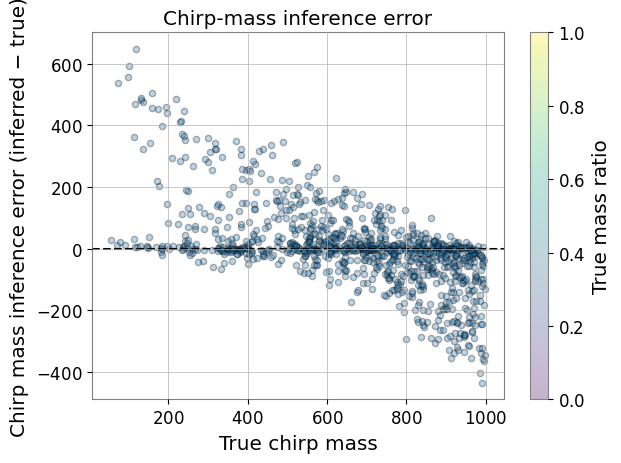

In [6]:
import matplotlib.pyplot as plt
import numpy as np

true_mr = np.array(true_mr)
true_cm = np.array(true_cm)




# ------------------------------------------------------------
# Error bars
# ------------------------------------------------------------

#plt.errorbar(
#    true_cm,
#    chirp_mass_error,
#    yerr=chirp_mass_std,
#    fmt="none",
#    capsize=4,
#    alpha=0.5,
#    color="gray",
#)

# ------------------------------------------------------------
# Colored scatter points
# ------------------------------------------------------------

sc = plt.scatter(
    true_cm,
    chirp_mass_error,
    #c=true_mr,
    #cmap="viridis",
    s=20,
    edgecolor="black",
    alpha=0.3
)

# ------------------------------------------------------------
# Reference line
# ------------------------------------------------------------

plt.axhline(0, linestyle="--", color="black")

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = plt.colorbar(sc)
cbar.set_label("True mass ratio")

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("True chirp mass")
plt.ylabel("Chirp mass inference error (inferred − true)")

plt.title("Chirp-mass inference error")

plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
cm_err = np.asarray(chirp_mass_error)

mean_error = np.mean(cm_err)          # signed average bias (over/under-estimation)
mean_abs_error = np.mean(np.abs(cm_err))  # average magnitude of deviation
rms_error = np.sqrt(np.mean(cm_err**2))   # RMS deviation, penalizes outliers more
std_error = np.std(cm_err)            # spread of the errors around their mean

print(f"Mean error (bias):      {mean_error:.3f}")
print(f"Mean absolute error:    {mean_abs_error:.3f}")
print(f"RMS error:              {rms_error:.3f}")
print(f"Std of error:           {std_error:.3f}")

Mean error (bias):      2.377
Mean absolute error:    86.579
RMS error:              136.248
Std of error:           136.228


In [8]:
pp_values_chirp_mass = []
pp_values_mass_ratio = []

result_files = sorted(os.listdir(f"/scratch/tpausch/test_data/{name}/results"))

for fname in result_files:

    with open(f"/scratch/tpausch/test_data/{name}/results/{fname}", "rb") as f:

        payload = pickle.load(f)

        theta_true = payload["theta_true"]
        result = payload["result"]

        posterior_samples = result.samples


        # ============================================================
        # Chirp mass PP value
        # ============================================================

        cm_samples = posterior_samples["chirp_mass"]

        pp_cm = np.mean(
            cm_samples < theta_true["chirp_mass"]
        )

        pp_values_chirp_mass.append(pp_cm)


        # ============================================================
        # Mass ratio PP value
        # ============================================================

        #q_samples = posterior_samples["mass_ratio"]
#
        #pp_q = np.mean(
        #    q_samples < theta_true["mass_ratio"]
        #)
#
        #pp_values_mass_ratio.append(pp_q)




In [9]:
import matplotlib.pyplot as plt


def plot_pp(pp_values, label):

    pp_values = np.array(pp_values)

    sorted_pp = np.sort(pp_values)

    n = len(sorted_pp)

    empirical_cdf = np.arange(1, n + 1) / n

    x = np.linspace(0, 1, 200)

    sigma = np.sqrt(x * (1 - x) / n)

    plt.figure(figsize=(6, 6))

    # Ideal calibration
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Ideal calibration",
    )


    # Empirical PP curve
    plt.plot(
        sorted_pp,
        empirical_cdf,
        marker="o",
        label=label,
    )

    plt.xlabel("Credible level")
    plt.ylabel("Fraction of injections")

    plt.title(f"PP Plot: {label}")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

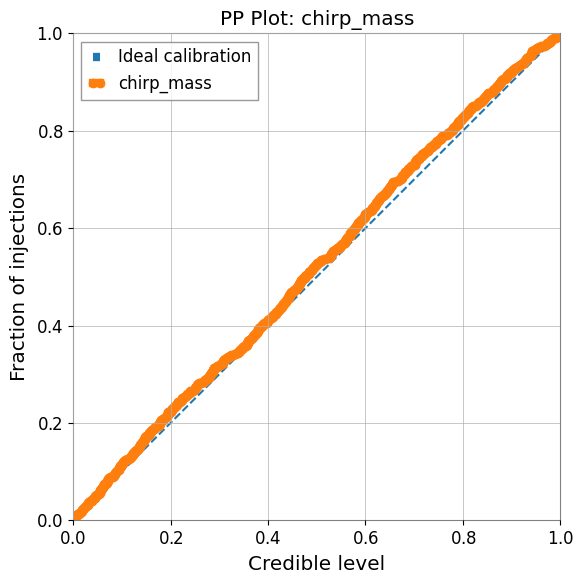

In [10]:

plot_pp(
    pp_values_chirp_mass,
    "chirp_mass",
)

#plot_pp(
#    pp_values_mass_ratio,
#    "mass_ratio",
#)

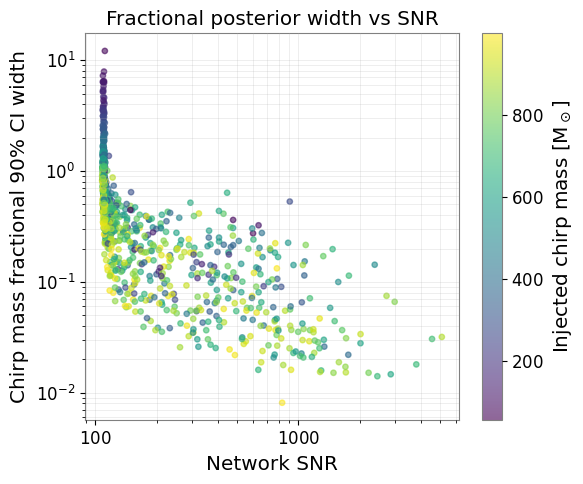

In [11]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt



snrs = []
ci90_widths = []
chirp_masses = []

result_files = sorted(os.listdir(f"/scratch/tpausch/test_data/{name}/results"))

for fname in result_files:

    with open(f"/scratch/tpausch/test_data/{name}/results/{fname}", "rb") as f:

        payload = pickle.load(f)
    
    theta_true = payload["theta_true"]
    result = payload["result"]
    snr = payload["network_snr"]

    samples = result.samples["chirp_mass"].to_numpy()  # adjust if result.samples is a DataFrame

    ci90 = np.percentile(samples, 95) - np.percentile(samples, 5)

    snrs.append(snr)
    ci90_widths.append(ci90)
    chirp_masses.append(theta_true["chirp_mass"])

snrs = np.array(snrs)
ci90_widths = np.array(ci90_widths)
chirp_masses = np.array(chirp_masses)

frac_widths = ci90_widths / chirp_masses  # relative width, dimensionless

plt.figure(figsize=(6, 5))
sc = plt.scatter(snrs, frac_widths, c=chirp_masses, cmap="viridis", alpha=0.6, s=15)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Network SNR")
plt.ylabel("Chirp mass fractional 90% CI width")
plt.colorbar(sc, label="Injected chirp mass [M$_\\odot$]")
plt.title("Fractional posterior width vs SNR")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()